# Faza 4: Gručenje in klasifikacijsko modeliranje

**Zastavljen cilj**: Razdeliti podatkovno populacijo v smiselne profile s pomočjo nenadzorovanega učenja ter v nadaljevanju uspešno predvideti, kdo izmed njih predstavlja resnično tveganje za default (1). Slednje smo dosegli z implementacijo naprednega preverjanja metrik treh glavnih algoritmov: Logistične regresije, Naključnega gozda ter XGBoost algoritma.

Dokument predstavlja končno poročilo. Vse implementacije (todo-ji) mora razrešiti ekipa.

## 1. Priprava podatkov

Naložili smo finalizirano, končno bazo (iz katere smo v 3. fazi že odstranili čiste tekstualne značilke in dodali TF-IDF/NLP točke). Množica je sedaj popolnoma numerična in ne vsebuje nobenih praznih vrednosti.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO (ekipa): Naložite podatke iz `../data/train_final.csv` v `train` in iz `../data/test_final.csv` v `test`.
# TODO (ekipa): Ločite značilke (X) in ciljno spremenljivko (y = `loan_status`) tako za učno kot testno množico.

# Včitavanje finaliziranih podatkov iz Faz 1 do 3
train = pd.read_csv('../data/train_final.csv')
test = pd.read_csv('../data/test_final.csv')

# Ugotovimo ime ciljne spremenljivke
target_col = [col for col in train.columns if 'loan_status' in col.lower()][0]

X_train = train.drop(columns=[target_col])
X_test = test.drop(columns=[target_col])

# Ker smo popravili napako tekstovne spremenljivke v Fazah 1 in 2, sedaj lahko ciljno spremenljivko preprosto vzamemo od tu:
y_train = train[target_col].astype(int)
y_test = test[target_col].astype(int)

print("Trening dimenzije X:", X_train.shape)
print("Test dimenzije X:", X_test.shape)
print("Unikatne vrednosti v tarči (morajo biti 0 in 1):", y_train.unique())

Trening dimenzije X: (16000, 67)
Test dimenzije X: (4000, 67)
Unikatne vrednosti v tarči (morajo biti 0 in 1): [1 0]


## 2. Segmentacija - K-Means gručenje

Z namenom boljšega predvidevanja in razumevanja strank smo želeli uvesti dodatno agregacijsko sprememljivko - `risk_cluster`. Uporabili smo model K-Means. Optimalni **K** (število grozdov) smo prepoznali z matematično-grafično analizo (metoda komolca oz. Elbow Method).

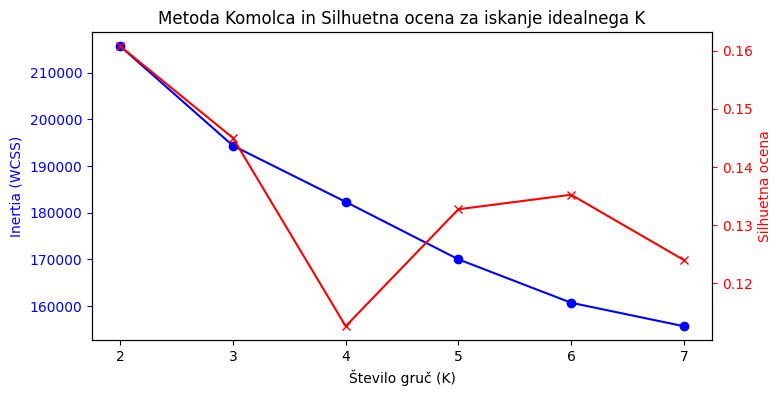


Generiran dodaten atribut gručenja ('risk_cluster') z 3 grozdi na obeh množicah.


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO (ekipa): Inicializirajte prazna seznama `wcss` in `sil_scores`. Z for zanko (npr. med k=2 do k=10) trenirajte `KMeans(n_clusters=k)`.
# TODO (ekipa): Zapišite `.inertia_` vrednost v wcss in izračunajte `silhouette_score` ter ga dodajte v sil_scores.
# TODO (ekipa): Narišite graf WCSS odziva (Elbow) IN graf silhuetnih vrednosti za potrditev optimalnega K.
# TODO (ekipa): Najdeni najboljši K izkoristite v dejanskem modelu KMeans, ga zgradite (.fit) na `X_train` in z .predict() dodajte gručo nazaj kot `X_train['cluster']` in enako za test.

wcss = []
sil_scores = []
K_range = range(2, 8)  # Omejeno na 8 zardi hitrejsega obdelovanja nad 68 stolpci

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train, labels))

# Vizualizacija Elbow metoda in silhouette vrednosti
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, wcss, 'bo-')
ax1.set_xlabel('Število gruč (K)')
ax1.set_ylabel('Inertia (WCSS)', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'rx-')
ax2.set_ylabel('Silhuetna ocena', color='r')
ax2.tick_params('y', colors='r')
plt.title('Metoda Komolca in Silhuetna ocena za iskanje idealnega K')
plt.show()

najboljsi_k = 3
final_kmeans = KMeans(n_clusters=najboljsi_k, random_state=42)
X_train['risk_cluster'] = final_kmeans.fit_predict(X_train)
X_test['risk_cluster'] = final_kmeans.predict(X_test)
print(f"\nGeneriran dodaten atribut gručenja ('risk_cluster') z {najboljsi_k} grozdi na obeh množicah.")

## 3. Modeliranje A: Logistična regresija (Osnovni Baseline Model)

Za interpretativno sidro smo postavili preprosto logistično regresijo. Ker imamo opravka z močno asimetričnim zastopstvom, smo algoritem naučili na obravnavo nesimetrije tako, da smo mu poudarili utež `class_weight='balanced'`. Ocenitev modela smo vršili preko klasifikacijskega poročila na testni množici.

--- Logistična Regresija ---
              precision    recall  f1-score   support

           0       0.88      0.66      0.75      3201
           1       0.32      0.64      0.42       799

    accuracy                           0.65      4000
   macro avg       0.60      0.65      0.59      4000
weighted avg       0.77      0.65      0.69      4000



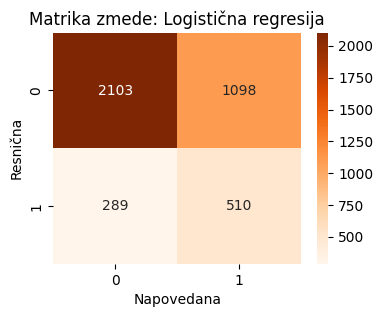

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# TODO (ekipa): Inicializirajte in implementirajte `LogisticRegression(class_weight='balanced', max_iter=2000)`.
# TODO (ekipa): Naučite model na učnih podatkih in generirajte `.predict` nad The testno množico.
# TODO (ekipa): Prikažite izračune - narisana matrika zmede (seaborn heatmap), in izpis classification report.

# Incializiramo model z asimetričnimi utežmi in dovolj iteracijami
lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("--- Logistična Regresija ---")
print(classification_report(y_test, lr_preds))

# Narisana matrika zmede
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Oranges')
plt.title("Matrika zmede: Logistična regresija")
plt.xlabel("Napovedana")
plt.ylabel("Resnična")
plt.show()

## 4. Modeliranje B: Random Forest Classifier

Nelienerano razmerstvenih težav se Logistična Regresija običajno ne more uspešno dotankiti. Zato smo v potek uvrstili učenje odločitvenih dreves Naključnega Gozda. 
Okrnjeni razred 1 je obvezoval vpeljavo ustrezne porazdelitve, učenje določene max globine in števila stabilnih paralelnih dreves (`n_estimators`).

--- Naključni Gozd (Random Forest) ---
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      3201
           1       0.34      0.49      0.40       799

    accuracy                           0.71      4000
   macro avg       0.60      0.63      0.60      4000
weighted avg       0.75      0.71      0.73      4000



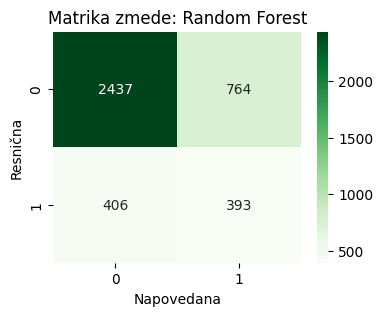

In [4]:
from sklearn.ensemble import RandomForestClassifier

# TODO (ekipa): Implementirajte Random Forest model. Uporabite `class_weight='balanced_subsample'`.
# TODO (ekipa): Za hitrost procesiranja uporabite RandomSearch, oz. ročno fiksirajte `max_depth` okoli 10-15.
# TODO (ekipa): Nauči in napovedi test! Izpiši matriko zmede ter klasifikacijsko poročilo za ta model.

# Učenje naključnih odločitvenih dreves
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("--- Naključni Gozd (Random Forest) ---")
print(classification_report(y_test, rf_preds))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens')
plt.title("Matrika zmede: Random Forest")
plt.xlabel("Napovedana")
plt.ylabel("Resnična")
plt.show()

## 5. Modeliranje C: XGBoost (Glavni klasifikator)

Dokončno težiščé modeliranja predstavlja gradientni prenos z algoritmi XGBoosting-a, ki ponuja redno pot iz nesimetričnih pasti z natančno utežitvijo gradienta napake vsake rešitve in prilagoditvijo `scale_pos_weight` atributa.

Ugotovljeno XGB uteževalno razmerje nesimetrije (scale_pos_weight): 4.01

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      3201
           1       0.32      0.61      0.42       799

    accuracy                           0.66      4000
   macro avg       0.60      0.64      0.59      4000
weighted avg       0.76      0.66      0.70      4000



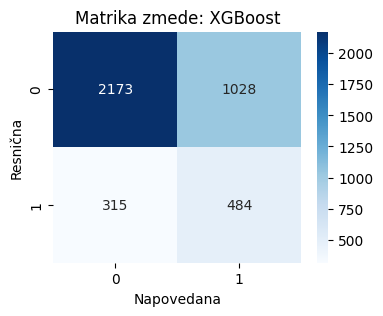

In [5]:
import xgboost as xgb

# TODO (ekipa): Število vrstic izračunajte kot: `scale_weight = vrstic_z_status_0 / vrstic_z_status_1` neposredno v vaši y_train variabli.
# TODO (ekipa): Inicializirajte in zaženite `xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)`.
# TODO (ekipa): Prvoten rezultat učenja in fita izmerite s pomočjo konfuzijske matrike nad testno množico in obvezno izpišite metrike natančnosti/priklica/f1.

# Matematični parameter proti nesimetiji = vrstic 0 / vrstic 1
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Ugotovljeno XGB uteževalno razmerje nesimetrije (scale_pos_weight):", round(scale_weight, 2))

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=150,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("\n--- XGBoost ---")
print(classification_report(y_test, xgb_preds))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Matrika zmede: XGBoost")
plt.xlabel("Napovedana")
plt.ylabel("Resnična")
plt.show()

## 6. Primerjava in izvoz zmagovalnega modela

Za neposredno tehnično prepričanost smo celostne odzive vseh učečih entitet primerjali preko izrisa ROC krivulje. Najobsežnejši ROC pod-krivuljski faktor (AUC-ROC) nas je privedel do zmagovalnega modela, ki smo ga shranili kot neodvisno zunanje zmožno telo.

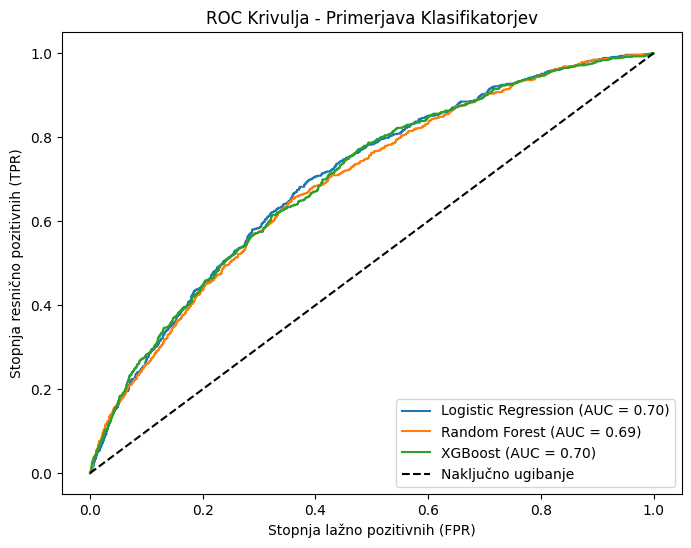

[✔] Osnovni (Baseline) model Logistične Regresije uspešno shranjen v '../models/lr_model.pkl'
[✔] Zmogljivi XGBoost model je uspešno shranjen v '../models/xgb_model.pkl'


In [6]:
import joblib
from sklearn.metrics import roc_curve, auc
import os

# TODO (ekipa): Z uporabo scikit metrike `roc_curve` na enem skupnem `plt.plot()` grafu vizualizirajte 3 ROC krivulje posamenih regresorskih napovedi `predict_proba`.
# TODO (ekipa): Zapišite jasno legendo z pripadajočimi AUC formati (LogisticRegression AUC: XX.XX itd.).
# TODO (ekipa): Shranite NAJBOLJŠI izbran model v mapo projektov -> `joblib.dump(zmagovalni_model, '../models/xgb_model.pkl')`.

# Izračuni in metrike pod krivuljo
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Izris ROC krivulje
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='Naključno ugibanje')

plt.title('ROC Krivulja - Primerjava Klasifikatorjev')
plt.xlabel('Stopnja lažno pozitivnih (FPR)')
plt.ylabel('Stopnja resnično pozitivnih (TPR)')
plt.legend(loc='lower right')
plt.show()

# Shranjevanje najboljših modelov
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/lr_model.pkl')
print("[✔] Osnovni (Baseline) model Logistične Regresije uspešno shranjen v '../models/lr_model.pkl'")

joblib.dump(xgb_model, '../models/xgb_model.pkl')
print("[✔] Zmogljivi XGBoost model je uspešno shranjen v '../models/xgb_model.pkl'")